# 定義模型類別與建立模型

In [10]:
from tensorflow.keras.layers import Dense
import tensorflow as tf

class MLP_Model(tf.keras.Model): # 定義模型子類別
  def __init__(self): # 初始化
    super(MLP_Model, self).__init__(name='MLP')
    self.h1_layer = Dense(256, activation='relu') # 隱藏層
    self.out_layer = Dense(10, activation='softmax') # 輸出層

  def call(self, inputs): # 定義call方法
    h1 = self.h1_layer(inputs)
    y_predict = self.out_layer(h1)
    return y_predict

model = MLP_Model()
# model.build(input_shape=(None, 784))  # 設定輸入層形狀
model(tf.zeros((1, 784)))
model.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (1, 256)               │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 10)                │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

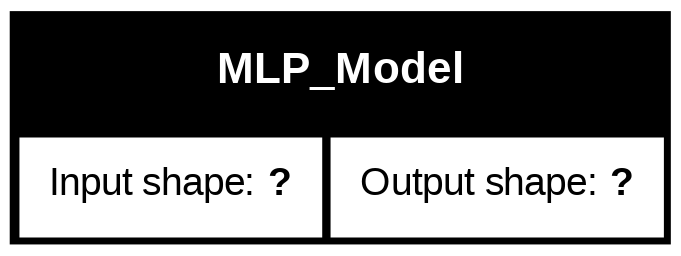

In [11]:
# Model subclassing 模型無模型結構
tf.keras.utils.plot_model(model, 'model.png', show_shapes=True)

# Model Subclassing  API建立CNN模型

In [14]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Softmax
import tensorflow as tf

class CNN_Model(tf.keras.Model): # 定義CNN模型類別，繼承自tf.keras.Model
  def __init__(self): # 初始化CNN模型的結構
    super(CNN_Model, self).__init__(name='CNN')
    # 定義CNN模型的層次結構
    self.conv1 = Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu') # 卷積層1：32個5x5的卷積核，使用ReLU激活函數，輸出大小與輸入相同（padding='same'）
    self.max_pool1 = MaxPooling2D(pool_size=(2,2)) # 池化層1：使用2x2的池化窗口，將特徵圖的大小減半

    self.conv2 = Conv2D(filters=64, kernel_size=(5,5), padding='same', activation='relu') # 卷積層2：64個5x5的卷積核，使用ReLU激活函數，輸出大小與輸入相同（padding='same'）
    self.max_pool2 = MaxPooling2D(pool_size=(2,2)) # 池化層2：使用2x2的池化窗口，將特徵圖的大小減半

    self.flatten = Flatten() # 展平層：將3D特徵圖展平為1D向量
    self.fc1 = Dense(750, activation='relu') # 全連接層1：750個神經元，使用ReLU激活函數
    self.dropout = Dropout(0.5) # Dropout層：隨機丟棄50%的神經元，以防止過擬合
    self.output_layer = Dense(10) # 輸出層：10個神經元，使用softmax激活函數，輸出為10類的概率分布
    self.softmax = Softmax()

  def call(self, inputs): # 定義CNN模型的前向傳播過程
      x = self.conv1(inputs) # 卷積層1
      x = self.max_pool1(x) # 池化層1
      x = self.conv2(x) # 卷積層2
      x = self.max_pool2(x) # 池化層2
      x = self.flatten(x) # 展平層
      x = self.fc1(x) # 全連接層1
      x = self.dropout(x) # Dropout層
      x = self.output_layer(x) # 輸出層
      output = self.softmax(x) # Softmax層，輸出為10類的概率分布
      return output

model = CNN_Model()
model.build(input_shape=(None, 32, 32, 3))
model.call(tf.keras.layers.Input(shape=(32, 32, 3)))
model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 750)            │     3,072,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 750)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         7,510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,133,956 (11.96 MB)

 Trainable params: 3,133,956 (11.96 MB)

 Non-trainable params: 0 (0.00 B)

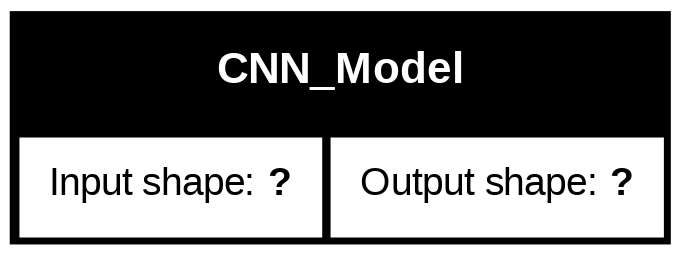

In [15]:
tf.keras.utils.plot_model(model, 'model.png', show_shapes=True)